In [3]:
import seaborn as sns
import numpy as np
import sctop as top
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

Possible directions

What's the minimum amount of information we need to include in our model to capture the correct changes in proportion as a result of change in signaling?

Do we need to have some kind of threshold response, to measure "none, low, high" levels of signaling?

Do we need combinatorial signaling?

Can we find some structure in the matrices (vs. purely random matrices)? Some latent space of signaling?

# Data

[A map of signaling responses in the human airway epithelium](https://www.sciencedirect.com/science/article/pii/S2405471224000590)

Control + 17 conditions [GSE246368](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE246368)

"Human bronchial epithelial cells were cultured at air-liquid interface (ALI) without treatment to drive differentiation into a pseudo- stratified epithelium that recapitulates the physiological cell types of the airway. The differentiated luminal cells were then stripped through calcium depletion, leaving the remaining basal cells to regenerate the tissue. This was done in the presence of a signaling agonist added to each well at a dosage 10- to 100-fold greater than the IC50. One condition was kept unperturbed for control."


Control + OSM + Ifng [GSE246441](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE246441)

In [4]:
osm_ifng = sc.read_h5ad('/Users/maria/github/phenotype-signaling/GSE246441_all_10x_data.h5ad')
many_conditions = sc.read_h5ad('/Users/maria/github/phenotype-signaling/GSE246368_all_data.h5ad')

In [5]:
cellchatdb = pd.read_csv('/Users/maria/github/phenotype-signaling/cellchatdb.human.csv', index_col=0)

# Phenotype-signal model with consumer-resource-like behavior

$$
\frac{dN_\mu}{dt} = \sum_{\nu \alpha} T_{\mu \nu} c_{\nu \alpha} L_{\alpha} N_{\nu} - \sum_{\gamma \beta} T_{\gamma \mu} c_{\mu \beta} L_{\beta} N_{\mu} - m_{\mu} N_{\mu}
$$

$$
\frac{dL_{\alpha}}{dt} = k_{\alpha} - r L_{\alpha} - \sum_{\mu \nu} T_{\mu \nu} c_{\nu \alpha} N_{\mu} L_{\alpha} + \sum_{\gamma} P_{\beta \gamma } N_{\gamma} 
$$

Variables:
- $N_{\mu}$: number of cells of cell type $\mu$
- $L_{\alpha}$: number of ligands for pathway $\alpha$
- $T_{\mu \nu}$: probability of transitioning from cell type $\nu$ to cell type $\mu$
- $c_{\nu \alpha}$: responsivity of cell type $\nu$ to pathway $\alpha$
- $m_{\mu}$: "mortality" of cell type $\mu$ (cell turnover rate for a given cell type?)
- $k_{\alpha}$: external supply of ligands for pathway $\alpha$
- $r$: dissociation rate of ligands
- $P_{\gamma \beta}$: production of ligand $\beta$ by cell type $\gamma$

Parameters from gene expression:
- Use Hopfield-like proximity-based likelihood for cell-type transition matrix: $T_{\mu \nu} = \frac{e^{- \beta ||\xi_{\mu} - \xi_{\nu}||^2}}{\sum_{\gamma} e^{- \beta ||\xi_{\mu} - \xi_{\gamma}||^2}}$ where $\xi_{\mu}$ is the gene expression profile for cell type $\mu$
- Combine receptor availibility with information about ligand-binding to find the phenotype-specific pathway responsivity: $c_{\nu \alpha} = \sum_{i, l}^{N_r} \xi_{\nu i} B_{i l} P_{l \alpha}$ where $i$ is summing over the receptors, $B$ is a binary matrix indicating whether ligand $l$ binds to receptor $i$ (can use CellChat to sum over interacting ligand-receptor pairs), and $P_{l \alpha}$ groups ligand-receptor pairs by pathway
- Use gene expression of ligand $\beta$ in cell type $\gamma$ for $P_{\gamma \beta}$

Free parameters: $m_{\mu}$, $d$

# 1. Processing the data

- Find average gene expression profiles for basal, club, ciliated, and goblet with sctop.process(..., average=True)
- Extract parameters for the model using CellChatDB and the average gene expression profiles

In [ ]:
phenotypes = ['Basal', 'Club', 'Multiciliated'] # take the 3 most abundant types to start
control_data = many_conditions[many_conditions.obs['condition'] == 'None'] # take control condition (no signals added)
df_list = []

data_to_use = control_data

for ptype in phenotypes: 
    type_mask = data_to_use.obs['cell_states'] == ptype
    indices = data_to_use.obs[type_mask].index
    processed_counts = top.process(data_to_use[indices].X.T.toarray(), average=True)
    processed_counts.index = data_to_use.var.index
    processed_counts.columns = [ptype]
    df_list += [processed_counts]

xi = pd.concat(df_list, axis=1)

In [15]:
from itertools import combinations

# Add retinoic acid receptors
retinoic_receptors = ['RARA', 'RARB' 'RARG']

# Add genes encoding enzymes for producing retinoic acid 
retinoic_production = ['ALDH1A1', 'ALDH1A2', 'ALDH1A3']

# Update CellChatDB to include retinoic acid
signaldb = cellchatdb.copy()

RA_rows = []

for producer in retinoic_production:
    for receptor in retinoic_receptors:
        new_row = {'interaction.interaction_name': f'{producer}_{receptor}',
                'interaction.pathway_name': 'RA',
                'interaction.ligand': producer,
                'interaction.receptor': receptor
                }
        
        RA_rows += [pd.DataFrame(new_row, index=[f'{producer}_{receptor}'])]

signaldb = pd.concat([signaldb, pd.concat(RA_rows)])

In [ ]:
genes = xi.index

ligands = np.intersect1d(genes, signaldb['interaction.ligand'])
receptors = np.intersect1d(genes, signaldb['interaction.receptor'])

pathways_included = np.array([])

for l in ligands:
    mask = signaldb['interaction.ligand'] == l
    these_pathways = signaldb[mask]['interaction.pathway_name'].values
    pathways_included = np.append(pathways_included, these_pathways)

pathways = np.unique(pathways_included)


print(f'Data includes {len(ligands)} ligands and {len(receptors)} receptors')
print(f'(Out of {len(signaldb['interaction.ligand'].unique())} possible ligands and {len(signaldb['interaction.receptor'].unique())} possible receptors in the CellChat database)')

print(f'\n{len(pathways)} out of {len(signaldb['interaction.pathway_name'].unique())} possible pathways')

Data includes 532 ligands and 359 receptors
(Out of 549 possible ligands and 509 possible receptors in the CellChat database)

221 out of 224 possible pathways


In [17]:
# Binary receptor x ligand interaction matrix from CellChatDB
lr_pairs = (
    signaldb[['interaction.receptor', 'interaction.ligand']]
)

receptor_ligand_matrix = pd.crosstab(
    lr_pairs['interaction.receptor'],
    lr_pairs['interaction.ligand']
).astype(int)

receptor_ligand_matrix = receptor_ligand_matrix.loc[receptors, ligands]

# Cell type transition tensors

Ligand-specific transition tensor, same softmax form as $T_{\mu\nu}$ but with an added term for the production or responsivity difference:

$$T^\alpha_{\mu\nu} = \frac{e^{-\beta \|\xi_\mu - \xi_\nu\|^2 + \gamma \, \Delta^\alpha_{\mu\nu}}}{\sum_{\nu'} e^{-\beta \|\xi_\mu - \xi_{\nu'}\|^2 + \gamma \, \Delta^\alpha_{\mu\nu'}}}$$

where $\Delta^\alpha_{\mu\nu}$ is the scaled squared difference (production or responsivity) for ligand $\alpha$ between cell types $\mu$ and $\nu$:

$$\Delta^{\alpha, \mathrm{prod}}_{\mu\nu} = (s\, P_{\alpha\mu} - s\, P_{\alpha\nu})^2, \qquad \Delta^{\alpha, \mathrm{resp}}_{\mu\nu} = (s\, c_{\mu\alpha} - s\, c_{\nu\alpha})^2$$

The scale factor $s = n_\text{genes} / n_\text{ligands}$ corrects for the dimensionality mismatch between $\|\xi_\mu - \xi_\nu\|^2$ (which sums over $\sim n_\text{genes}$ dimensions) and the ligand differences (which involve a single dimension per ligand $\alpha$), putting both terms on a comparable magnitude.

- $\gamma = 0$: recovers the ligand-independent base matrix $T_{\mu\nu}$
- $\gamma > 0$: increases transition probability toward cell types that differ more in production/responsivity for ligand $\alpha$


Add [basal medium](https://bioscience.lonza.com/lonza_bs/CH/en/Primary-and-Stem-Cells/p/000000000000185308/BEGM-Bronchial-Epithelial-Cell-Growth-Medium-BulletKit)

	1 x Orange Cap Vial with BPE, 2.00 mL
	1 x Lilac Cap Vial with Insulin, 0.50 mL
	1 x Natural Cap Vial with Hydrocortisone, 0.50 mL
	1 x Red Cap Vial with GA-1000, 0.50 mL
	1 x Amber Vial with Retinoic Acid, 0.50 mL
	1 x Natural Cap Vial with Transferrin, 0.50 mL
	1 x Amber Vial with Triiodothyronine, 0.50 mL
	1 x Amber Vial with Epinephrine, 0.50 mL
	1 x Green Cap Vial with hEGF, 0.50 mL


| Ingredient | Mapping to pathways/receptors/ligands |
| -------- | -------- |
| Bovine Pituitary Extract, 2.00 mL |  Most similar: FGF, EGF, IGF/PDGF |
| Insulin, 0.50 mL | INS/IGF |
| Retinoic Acid, 0.50 mL | Nuclear receptor: RAR (not in CellChat)|
| hEGF, 0.50 mL | EGF |

In [18]:
medium_pathways = ['FGF', 'EGF', 'IGF', 'PDGF', 'INS', 'IGF']
medium_pathways_cellchat = np.array([])

# Find the actual names used in cellchat
for pathway in medium_pathways:
    find_in_cellchat = np.unique([name for name in signaldb['interaction.pathway_name'] if pathway in name])
    medium_pathways_cellchat = np.append(medium_pathways_cellchat, find_in_cellchat)

medium_pathways_cellchat = np.unique(medium_pathways_cellchat)
print(medium_pathways_cellchat)

# remove 'VEGF'
medium_pathways_cellchat = ['EGF', 'FGF', 'IGF', 'INSULIN', 'PDGF', 'RA']
print(medium_pathways_cellchat)

['EGF' 'FGF' 'IGF' 'INSULIN' 'PDGF' 'VEGF']
['EGF', 'FGF', 'IGF', 'INSULIN', 'PDGF', 'RA']


In [19]:
medium_ligands = np.array([])

for pathway in medium_pathways_cellchat:
    these_ligands = signaldb[signaldb['interaction.pathway_name'] == pathway]['interaction.ligand']
    medium_ligands = np.append(medium_ligands, these_ligands)

medium_ligands = np.unique(medium_ligands)
print(medium_ligands)

['ALDH1A1' 'ALDH1A2' 'ALDH1A3' 'AREG' 'BTC' 'EGF' 'EREG' 'FGF1' 'FGF10'
 'FGF16' 'FGF17' 'FGF18' 'FGF19' 'FGF2' 'FGF20' 'FGF21' 'FGF22' 'FGF23'
 'FGF3' 'FGF4' 'FGF5' 'FGF6' 'FGF7' 'FGF8' 'FGF9' 'HBEGF' 'IGF1' 'IGF2'
 'IGFL3' 'INS' 'PDGFA' 'PDGFB' 'PDGFC' 'PDGFD' 'TGFA']


In [20]:

supplied_pathways = pd.Series(np.zeros(len(pathways)), index=pathways)

for pathway in medium_pathways_cellchat:
    if pathway in supplied_pathways.index:
        supplied_pathways.loc[pathway] = 1


# 3. Multi-condition simulations with extended phenotypes

Simulate 3 conditions (medium only, medium + FGF2, medium + BMP4) using 6 cell types:
Basal, Club, Multiciliated, Ionocyte, Goblet, Tuft.


In [21]:
many_conditions.obs['cell_states'].value_counts()

cell_states
Basal            38208
Club             24659
Multiciliated    12527
Goblet            1324
Ionocyte           404
Tuft               246
Indeterminate      105
PNEC                95
Name: count, dtype: int64

In [70]:
# ── Extended phenotype set ──────────────────────────────────────────────────
phenotypes_ext = ['Basal',  'Multiciliated', 'Club', 'Goblet', 'Ionocyte', 'Tuft',]# 'PNEC']

# Take even sampling from all cell types -- 95 cells
num_cells = 245

rng = np.random.default_rng()

df_list_ext = []
for ptype in phenotypes_ext:
    type_mask = many_conditions.obs['cell_states'] == ptype
    indices = many_conditions.obs[type_mask].index

    # Subset to num_cells
    random_indices = rng.choice(indices, size=num_cells, replace=False)

    pc = top.process(many_conditions[random_indices].X.T.toarray(), average=True)
    pc.index = many_conditions.var.index
    pc.columns = [ptype]
    df_list_ext.append(pc)

xi_ext = pd.concat(df_list_ext, axis=1)
xi_nonneg_ext = xi_ext.clip(lower=0)

ligand_responsivity_ext = xi_nonneg_ext.loc[receptors].T.dot(receptor_ligand_matrix)
ligand_production_ext   = xi_nonneg_ext.loc[ligands]

# ── Aggregate to pathway level ──────────────────────────────────────────────
# Binary ligand x pathway matrix: 1 if ligand participates in that pathway
ligand_pathway_map = (
    signaldb[['interaction.ligand', 'interaction.pathway_name']]
    .drop_duplicates()
)
ligand_pathway_matrix = pd.crosstab(
    ligand_pathway_map['interaction.ligand'],
    ligand_pathway_map['interaction.pathway_name']
).reindex(index=ligands, columns=pathways, fill_value=0).astype(int)

# Sum responsivity / production over all ligands belonging to each pathway
pathway_responsivity_ext = ligand_responsivity_ext.dot(ligand_pathway_matrix)  # (n_ph x n_path)
pathway_production_ext   = ligand_pathway_matrix.T.dot(ligand_production_ext)   # (n_path x n_ph)

print(f'ligand_responsivity_ext:  {ligand_responsivity_ext.shape}  (n_phenotypes x n_ligands)')
print(f'ligand_production_ext:    {ligand_production_ext.shape}  (n_ligands x n_phenotypes)')
print(f'pathway_responsivity_ext: {pathway_responsivity_ext.shape}  (n_phenotypes x n_pathways)')
print(f'pathway_production_ext:   {pathway_production_ext.shape}  (n_pathways x n_phenotypes)')


ligand_responsivity_ext:  (6, 532)  (n_phenotypes x n_ligands)
ligand_production_ext:    (532, 6)  (n_ligands x n_phenotypes)
pathway_responsivity_ext: (6, 221)  (n_phenotypes x n_pathways)
pathway_production_ext:   (221, 6)  (n_pathways x n_phenotypes)


# Transition matrix for extended phenotypes

In [236]:

# ── Transition matrix and pathway-specific tensors for extended phenotypes ───
from scipy.special import softmax

# beta = 80, gamma = 0.01 -- roughly matches

beta_base = 75.0
# gamma_ext = -10.0
gamma_ext = 0.01

# Low beta: equal probability of all
# High beta: stuck in basal, or takes very long time to get to equilibrium

xi_vals   = xi_ext[phenotypes_ext].values
xi_T_ext = xi_vals.T  # (n_phenotypes, n_genes)
D_ext = np.sum((xi_T_ext[:, np.newaxis, :] - xi_T_ext[np.newaxis, :, :])**2, axis=-1)

cell_type_transitions_ext = pd.DataFrame(
    softmax(-beta_base * D_ext, axis=1),
    index=phenotypes_ext, columns=phenotypes_ext
)

# Scale by n_genes / n_pathways so pathway differences are on the same scale as D_ext
# (D_ext sums over n_genes dimensions; pathway differences involve a single dimension per pathway α)
n_genes_ext    = xi_vals.shape[0]
n_pathways_ext = len(pathways)
scale = n_genes_ext / n_pathways_ext

# Pathway-specific tensors
P_arr_ext = pathway_production_ext.values * scale    # (n_pathways, n_phenotypes)
C_arr_ext = pathway_responsivity_ext.values * scale  # (n_phenotypes, n_pathways)

# Squared pairwise differences of pathway-summed quantities:
# Δ^α_prod(μ,ν) = (Σ_l P_{lμ} − Σ_l P_{lν})² for ligands l in pathway α
prod_diff_norm_ext = (P_arr_ext[:, :, np.newaxis] - P_arr_ext[:, np.newaxis, :])**2  # (n_path, n_ph, n_ph)
C_T_ext = C_arr_ext.T  # (n_pathways, n_phenotypes)
resp_diff_norm_ext = (C_T_ext[:, :, np.newaxis] - C_T_ext[:, np.newaxis, :])**2      # (n_path, n_ph, n_ph)

# Base logits: -beta * D/D_max, broadcast over pathways
base_logits_ext = -beta_base * D_ext[np.newaxis, :, :]  # (1, n_ph, n_ph)
T_prod_ext = softmax(base_logits_ext + gamma_ext * prod_diff_norm_ext, axis=2)
T_resp_ext = softmax(base_logits_ext + gamma_ext * resp_diff_norm_ext, axis=2)

print(f'T_prod_ext shape: {T_prod_ext.shape}  (n_pathways x n_phenotypes x n_phenotypes)')
print(f'Row sums check (T_prod_ext[0]): {T_prod_ext[0].sum(axis=1)}')


T_prod_ext shape: (221, 6, 6)  (n_pathways x n_phenotypes x n_phenotypes)
Row sums check (T_prod_ext[0]): [1. 1. 1. 1. 1. 1.]


In [240]:
T_resp_ext

array([[[9.99999466e-01, 7.72317688e-10, 3.43604245e-07, 6.78886874e-08,
         3.13287094e-08, 9.01405470e-08],
        [7.72318091e-10, 9.99999987e-01, 8.35424282e-09, 2.04006445e-09,
         5.10715531e-10, 9.39829912e-10],
        [3.43603746e-07, 8.35422633e-09, 9.99998013e-01, 1.27716643e-06,
         8.73364307e-08, 2.70223908e-07],
        [6.78886275e-08, 2.04006159e-09, 1.27716715e-06, 9.99998584e-01,
         1.89399675e-08, 5.04107219e-08],
        [3.13287091e-08, 5.10715259e-10, 8.73365566e-08, 1.89399840e-08,
         9.99999456e-01, 4.06351279e-07],
        [9.01405213e-08, 9.39829155e-10, 2.70224224e-07, 5.04107521e-08,
         4.06351168e-07, 9.99999182e-01]],

       [[9.99999463e-01, 7.72664443e-10, 3.45726118e-07, 6.90304275e-08,
         3.13370526e-08, 9.02187719e-08],
        [7.72664849e-10, 9.99999987e-01, 8.38169385e-09, 2.06397964e-09,
         5.11434417e-10, 9.42243031e-10],
        [3.45725613e-07, 8.38167723e-09, 9.99998004e-01, 1.28045109e-06,
     

In [237]:

from scipy.integrate import solve_ivp

# ── ODE parameters ──────────────────────────────────────────────────────────
m_ext = 0.001
r_ext = 0.001

n_ph_ext   = len(phenotypes_ext)
n_path_ext = len(pathways)

C_ext = pathway_responsivity_ext.values   # (n_ph, n_path)
P_ext = pathway_production_ext.values     # (n_path, n_ph)

# Choose which cell-type transition matrix to use:
# T_resp_ext, based on pathway responsivity
# T_prod_ext, based on pathway productivity
T_alpha_ext         = T_resp_ext                                    # (n_path, n_ph, n_ph)
T_alpha_col_sum_ext = T_alpha_ext.sum(axis=1)                       # (n_path, n_ph)
TC_alpha_ext        = np.einsum('amn,na->ma', T_alpha_ext, C_ext)  # (n_ph, n_path)

# ── External supply vectors (indexed by pathway) ─────────────────────────────
k_none   = pd.Series(np.zeros(n_path_ext), index=pathways)
k_medium = supplied_pathways * 0.1

# Medium + FGF (boost entire FGF pathway)
k_fgf = k_medium.copy()
k_fgf.loc['FGF'] = 10

# Medium + BMP (boost entire BMP pathway)
k_bmp = k_medium.copy()
k_bmp.loc['BMP'] = 10

# ── ODE factory ─────────────────────────────────────────────────────────────
def make_dydt_ext(k_vec):
    k = k_vec.values
    def dydt(t, y):
        N = y[:n_ph_ext]
        L = y[n_ph_ext:]
        CL_w = C_ext * L
        gain_N = np.einsum('amn,na,n->m', T_alpha_ext, CL_w, N)
        loss_N = N * np.einsum('ma,am->m', CL_w, T_alpha_col_sum_ext)
        dN = gain_N - loss_N - m_ext * N
        consumption_L = L * (TC_alpha_ext.T @ N)
        production_L = P_ext @ N
        dL = k - r_ext * L - consumption_L + production_L
        return np.concatenate([dN, dL])
    return dydt

# ── Run 4 simulations ───────────────────────────────────────────────────────
N0_ext = np.zeros(n_ph_ext); N0_ext[0] = 1.0   # start all-Basal
L0_ext = np.zeros(n_path_ext)
y0_ext = np.concatenate([N0_ext, L0_ext])

t_span_ext = (0, 5000)
t_eval_ext = np.linspace(*t_span_ext, 1000)

conditions_k = {
    'No medium':    k_none,
    'Medium':       k_medium,
    'Medium + FGF': k_fgf,
    'Medium + BMP': k_bmp,
}

# Use Radau (implicit, stiff solver) with tighter tolerances to distinguish
# numerical noise from genuine oscillations.
solutions_ext = {}
for cond_name, k_vec in conditions_k.items():
    sol = solve_ivp(make_dydt_ext(k_vec), t_span_ext, y0_ext,
                    t_eval=t_eval_ext, method='Radau', rtol=1e-6, atol=1e-9)
    solutions_ext[cond_name] = sol
    print(f'{cond_name}: {"succeeded" if sol.success else "FAILED — " + sol.message}')


No medium: succeeded
Medium: succeeded
Medium + FGF: succeeded
Medium + BMP: succeeded


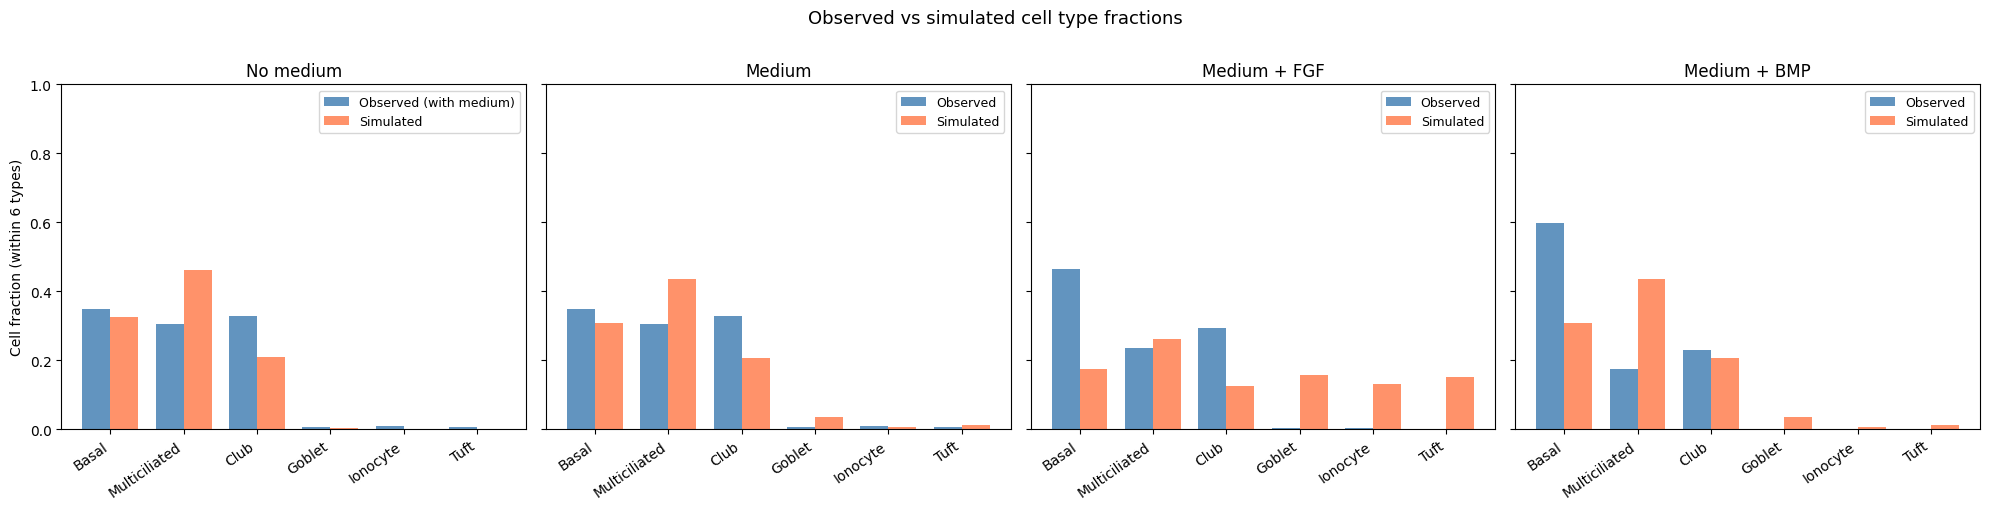

In [238]:

# ── Observed vs Simulated comparison ───────────────────────────────────────
# Map simulation condition names to dataset condition labels
data_condition_map = {
    'No medium':    'None',
    'Medium':       'None',
    'Medium + FGF': 'FGF2',
    'Medium + BMP': 'BMP4',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
x = np.arange(len(phenotypes_ext))
width = 0.38

for ax, (cond_name, data_cond) in zip(axes, data_condition_map.items()):
    # ── Observed fractions (normalized within the 6 phenotypes) ──
    cond_adata = many_conditions[many_conditions.obs['condition'] == data_cond]
    obs_counts = cond_adata.obs['cell_states'].value_counts().reindex(phenotypes_ext, fill_value=0)
    obs_fracs  = obs_counts / obs_counts.sum()

    # ── Simulated fractions (final time point, clipped non-negative) ──
    N_final   = solutions_ext[cond_name].y[:n_ph_ext, -1].clip(0)
    sim_fracs = N_final / N_final.sum() if N_final.sum() > 0 else N_final

    if cond_name == 'No medium':
        obs_label = 'Observed (with medium)'
    else:
        obs_label = 'Observed'

    bars_obs = ax.bar(x - width / 2, obs_fracs.values, width,
                      label=obs_label, color='steelblue', alpha=0.85)
    bars_sim = ax.bar(x + width / 2, sim_fracs,        width,
                      label='Simulated', color='coral',     alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(phenotypes_ext, rotation=35, ha='right', fontsize=10)
    ax.set_title(cond_name, fontsize=12)
    ax.set_ylim(0, 1)
    if ax is axes[0]:
        ax.set_ylabel('Cell fraction (within 6 types)')
    ax.legend(fontsize=9)

plt.suptitle('Observed vs simulated cell type fractions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


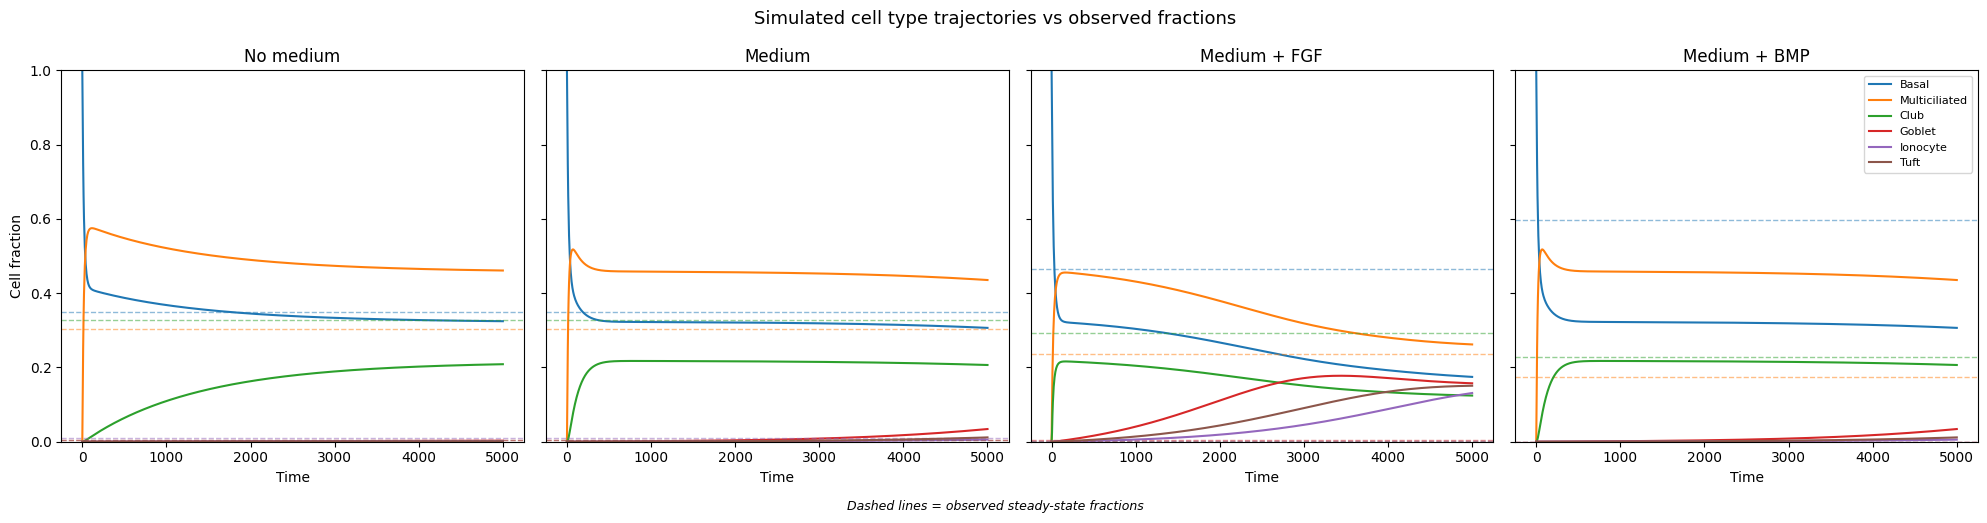

In [239]:

# ── Trajectory plots: simulated fractions over time, observed as dashed lines ──
data_condition_map = {
    'No medium':    'None',
    'Medium':       'None',
    'Medium + FGF': 'FGF2',
    'Medium + BMP': 'BMP4',
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, (cond_name, data_cond) in zip(axes, data_condition_map.items()):
    sol = solutions_ext[cond_name]
    N_sol = sol.y[:n_ph_ext, :]                          # (n_ph, n_t)
    N_sol_clipped = N_sol.clip(0)
    total = N_sol_clipped.sum(axis=0)
    total = np.where(total > 0, total, 1.0)
    fracs = N_sol_clipped / total                        # normalised fractions

    # Observed fractions (dashed horizontal lines)
    cond_adata = many_conditions[many_conditions.obs['condition'] == data_cond]
    obs_counts = cond_adata.obs['cell_states'].value_counts().reindex(phenotypes_ext, fill_value=0)
    obs_fracs  = obs_counts / obs_counts.sum()

    for i, ptype in enumerate(phenotypes_ext):
        ax.plot(sol.t, fracs[i], color=colors[i], label=ptype)
        ax.axhline(obs_fracs[ptype], color=colors[i], linestyle='--', alpha=0.5, linewidth=1)

    ax.set_xlabel('Time')
    ax.set_title(cond_name, fontsize=12)
    ax.set_ylim(0, 1)
    if ax is axes[0]:
        ax.set_ylabel('Cell fraction')
    if ax is axes[-1]:
        ax.legend(fontsize=8, loc='upper right')

# Shared legend note
fig.text(0.5, -0.02, 'Dashed lines = observed steady-state fractions',
         ha='center', fontsize=9, style='italic')
plt.suptitle('Simulated cell type trajectories vs observed fractions', fontsize=13)
plt.tight_layout()
plt.show()
